In [1]:
from functools import partial

import numpy as np
import xarray as xr
import pandas as pd
import pytest
from openeo_pg_parser_networkx.pg_schema import ParameterReference

from openeo_processes_dask.core import process_registry
from openeo_processes_dask.process_implementations.ml.curve_fitting import fit_curve, predict_curve
from openeo_processes_dask.process_implementations.math import *
from openeo_processes_dask.process_implementations.arrays import array_element
from openeo_processes_dask.process_implementations.cubes.general import dimension_labels
from tests.general_checks import assert_numpy_equals_dask_numpy, general_output_checks
from tests.mockdata import create_fake_rastercube

import matplotlib.pyplot as plt


In [2]:
from dask.distributed import Client

client = Client()
client

2023-01-02 15:15:50,667 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-mv2k15w4', purging
2023-01-02 15:15:50,668 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-xbzldct2', purging
2023-01-02 15:15:50,668 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-3ffbli6s', purging
2023-01-02 15:15:50,668 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-8b790zhn', purging


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 5.70 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38935,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 5.70 GiB
Comm: tcp://127.0.0.1:37729,Total threads: 2
Dashboard: http://127.0.0.1:32829/status,Memory: 1.42 GiB
Nanny: tcp://127.0.0.1:37087,


In [3]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 5.70 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38935,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 5.70 GiB
Comm: tcp://127.0.0.1:37729,Total threads: 2
Dashboard: http://127.0.0.1:32829/status,Memory: 1.42 GiB
Nanny: tcp://127.0.0.1:37087,


- This is the xarray without dask part to show how fit_curve works. Stick to small spatial and temporal extents.

In [5]:
timesteps = 150
spatial = 2
rang = np.linspace(0, 4*np.pi, timesteps)

# define data with y = 0 + 1 * cos() + 0.5 *sin()
curve = np.ones((spatial,timesteps)) * (np.cos(rang) + 0.5 * np.sin(rang)) + np.random.rand(spatial,timesteps)-np.random.rand(spatial,timesteps)
xdata = xr.DataArray(curve, coords=[
    np.arange(spatial), 
    pd.date_range("2018-01-01", "2020-01-01", 
    periods=timesteps)],
                        dims=["x", "time"])
print(xdata[0].max().values, xdata[0].min().values)

1.862325652694278 -1.945003826741996


In [6]:
def func_oeop(x, *parameters):
    # function with cos and sin: a + b*cos(2*pi/31557600*x) + c*sin(2*pi/31557600*x)
    a = array_element(**{'data': parameters, 'index': 0})
    b = array_element(**{'data': parameters, 'index': 1})
    c = array_element(**{'data': parameters, 'index': 2})
    # cos(2*pi/31557600*x)
    t1 = multiply(x = divide(x = multiply(x = 2, y = pi()), y = 31557600), y = x)
    cos1 = cos(**{'x': t1})
    # sin(2*pi/31557600*x)
    t2 = multiply(x = divide(x = multiply(x = 2, y = pi()), y = 31557600), y = x)
    sin1 = sin(**{'x': t2})
    # multiply and sum terms up
    m1 = multiply(**{'x': b, 'y': cos1})
    m2 = multiply(**{'x': c, 'y': sin1})
    sum1 = add(**{'x': a, 'y': m1})
    sum2 = add(**{'x': sum1, 'y': m2})
    return sum2

params = (fit_curve(xdata, parameters=[1, 1, 1], function=func_oeop, dimension='time'))
predicted = predict_curve(xdata, params, func_oeop, dimension='time',
                                labels=pd.date_range("2018-01-01", "2020-01-01", periods=timesteps))

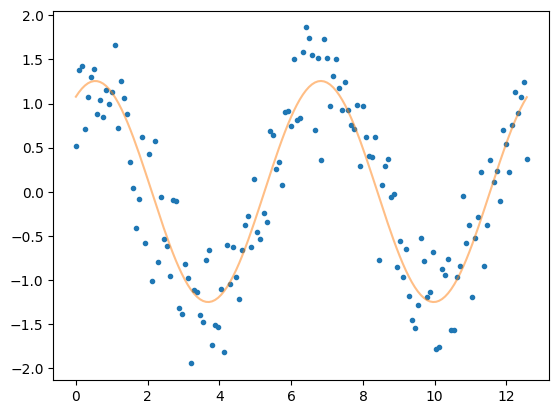

In [7]:
plt.plot(rang, xdata[0].values, '.')
plt.plot(rang, predicted[0].values, alpha=0.5)

- This is the dask xarray part. First, we create a fake dataset, then we load it with chunks and test fit_curve.

In [14]:
timesteps = 150
x = 1000
y = 1000
rang = np.linspace(0, 4 * np.pi, timesteps)
# define data with y = 0 + 1 * cos() + 0.5 *sin() 
curve = (
    np.ones((x, y, timesteps)) * (np.cos(rang) + 0.5 * np.sin(rang))
    + np.random.rand(x, y, timesteps) - np.random.rand(x, y, timesteps)
)
data = xr.DataArray(
    curve,
    coords=[
        np.arange(x),
        np.arange(y),
        pd.date_range("2018-01-01", "2020-01-01", periods=timesteps),
    ],
    dims=["x", "y", "time"],
)
#data = data.to_dataset(dim="time")
path = f"./dataarray.nc"
data.to_netcdf(path)

In [15]:
data = xr.open_dataarray("./dataarray.nc", chunks= {"x":100, "y":100, "time": 150})

In [16]:
data

<xarray.DataArray (x: 1000, y: 1000, time: 150)>
dask.array<open_dataset-aac03b1bad07f355cce815e05127ee7b__xarray_dataarray_variable__, shape=(1000, 1000, 150), dtype=float64, chunksize=(100, 100, 150), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) int64 0 1 2 3 4 5 6 7 8 ... 991 992 993 994 995 996 997 998 999
  * y        (y) int64 0 1 2 3 4 5 6 7 8 ... 991 992 993 994 995 996 997 998 999
  * time     (time) datetime64[ns] 2018-01-01 ... 2020-01-01

In [11]:
def func_oeop(x, *parameters):
    # function with cos and sin: a + b*cos(2*pi/31557600*x) + c*sin(2*pi/31557600*x)
    a = array_element(**{"data": parameters, "index": 0})
    b = array_element(**{"data": parameters, "index": 1})
    c = array_element(**{"data": parameters, "index": 2})
    # cos(2*pi/31557600*x)
    t1 = multiply(x=divide(x=multiply(x=2, y=pi()), y=31557600), y=x)
    cos1 = cos(**{"x": t1})
    # sin(2*pi/31557600*x)
    t2 = multiply(x=divide(x=multiply(x=2, y=pi()), y=31557600), y=x)
    sin1 = sin(**{"x": t2})
    # multiply and sum terms up
    m1 = multiply(**{"x": b, "y": cos1})
    m2 = multiply(**{"x": c, "y": sin1})
    sum1 = add(**{"x": a, "y": m1})
    sum2 = add(**{"x": sum1, "y": m2})
    return sum2

params = fit_curve(data, parameters=[0, 1, 0.5], function=func_oeop, dimension="time")
print(params.values)

- Modify the chunks to get different timescales, estimates of how long it takes: 

0. Data {"x":1000, "y":1000, "time": 150}, chunks {"x":100, "y":100, "time": 150}, parameters [0, 1, 0.5]: 10.45 min
1. Data {"x":1000, "y":1000, "time": 150}, chunks {"x":100, "y":100, "time": 150}, parameters [1, 1, 1]: 13.26 min
2. Data {"x":1000, "y":1000, "time": 150}, chunks {"x":50, "y":50, "time": 150}, parameters [1, 1, 1]: 15.37 min
3. Data {"x":1000, "y":1000, "time": 150}, chunks {"x":200, "y":200, "time": 150}, parameters [1, 1, 1]: 13.28 min
4. Data {"x":1000, "y":1000, "time": 150}, chunks {"x":1000, "y":1000, "time": 1}, parameters [1, 1, 1]: DIED after 1.46 min

5. Data {"x":2000, "y":2000, "time": 150}, chunks {"x":200, "y":200, "time": 150}, parameters [1, 1, 1]: 36.12 min
6. Data {"x":2000, "y":2000, "time": 150}, chunks {"x":100, "y":100, "time": 150}, parameters [1, 1, 1]: >81 min
7. Data {"x":2000, "y":2000, "time": 150}, chunks {"x":400, "y":400, "time": 150}, parameters [1, 1, 1]: 40.26 min

- Get the data from separate files, which only include one timestep:

8. Data {"x":1000, "y":1000, "time": 150}, chunks {"x":100, "y":100, "time": 1}, parameters [0, 1, 0.5]: 13.36 min

9. Data {"x":2000, "y":2000, "time": 150}, chunks {"x":200, "y":200, "time": 1}, parameters [0, 1, 0.5]: 58.28 min

9. Data {"x":3000, "y":3000, "time": 150}, chunks {"x":300, "y":300, "time": 1}, parameters [0, 1, 0.5]: DIED

10. Data {"x":3000, "y":3000, "time": 150}, chunks {"x":200, "y":200, "time": 1}, parameters [0, 1, 0.5]: DIED

- using xr.DataArray.chunk()

11. Data {"x":3000, "y":3000, "time": 150}, chunks {"x":200, "y":200, "time": 150}, parameters [0, 1, 0.5]: 156.06 min

12. Data {"x":10000, "y":10000, "time": 150}, chunks {"x":200, "y":200, "time": 150}, parameters [0, 1, 0.5]: DIED

13. Data {"x":10000, "y":10000, "time": 150}, chunks {"x":100, "y":100, "time": 150}, parameters [0, 1, 0.5]: DIED

14. Data {"x":10000, "y":10000, "time": 150}, chunks {"x":300, "y":300, "time": 150}, parameters [0, 1, 0.5]: DIED

15. Data {"x":10000, "y":10000, "time": 150}, chunks {"x":1000, "y":1000, "time": 150}, parameters [0, 1, 0.5]: DIED

16. Data {"x":10000, "y":10000, "time": 150}, chunks {"x":500, "y":500, "time": 150}, parameters [0, 1, 0.5]: DIED

In [1]:
paths = []

timesteps = 150
x = 10000
y = 10000
rang = np.linspace(0, 4 * np.pi, timesteps)
times = pd.date_range("2018-01-01", "2020-01-01", periods=timesteps)
# define data with y = 0 + 1 * cos() + 0.5 *sin()
for e, i in enumerate(rang):
    curve = (
        np.ones((x, y, 1)) * (np.cos(i) + 0.5 * np.sin(i)) + np.random.rand(x, y, 1) - np.random.rand(x, y, 1)
    )

    data = xr.DataArray(
        curve,
        coords=[
            np.arange(x),
            np.arange(y),
            [str(np.datetime64(times[e]))],
        ],
        dims=["x", "y", "time"],
    )
    data = data.to_dataset(dim="time")
    path = f"./data/timesteps/data_{e}.nc"
    paths.append(path)
    data.to_netcdf(path)

In [5]:
paths = [f"./data/timesteps/data_{e}.nc" for e in range(150)]
times = pd.date_range("2018-01-01", "2020-01-01", periods=150)

In [8]:
ds = xr.open_mfdataset(paths, chunks= {"x":500, "y":500, "time": 150})
da = ds.to_array(dim="time")
da["time"] = times

In [9]:
da = da.chunk(chunks={"x": 500, "y": 500, "time": 150})
da

<xarray.DataArray (time: 150, x: 10000, y: 10000)>
dask.array<rechunk-merge, shape=(150, 10000, 10000), dtype=float64, chunksize=(150, 500, 500), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) int64 0 1 2 3 4 5 6 7 ... 9993 9994 9995 9996 9997 9998 9999
  * y        (y) int64 0 1 2 3 4 5 6 7 ... 9993 9994 9995 9996 9997 9998 9999
  * time     (time) datetime64[ns] 2018-01-01 ... 2020-01-01

In [12]:
params = fit_curve(da, parameters=[0, 1, 0.5], function=func_oeop, dimension="time")
print(params.values)

HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 1:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 494 in H5O__attr_open_by_name(): can't locate attribute: '_QuantizeBitGroomNumberOfSignificantDigits'
    major: Attribute
    minor: Object not found
HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 1:
  #000: H5A.c line 528 in H5Ao

: 

: 